In [122]:
import pandas as pd

df = pd.read_csv("jbjy-vk9h_limpio.csv")
pd.options.display.float_format = '{:,.0f}'.format
print(df.shape)
df.head()

(850, 85)


,nombre_entidad,nit_entidad,departamento,ciudad,localizaci_n,orden,sector,rama,entidad_centralizada,proceso_de_compra,...,n_mero_de_documento_ordenador_del_gasto,nombre_supervisor,tipo_de_documento_supervisor,n_mero_de_documento_supervisor,nombre_ordenador_de_pago,tipo_de_documento_ordenador_de_pago,n_mero_de_documento_ordenador_de_pago,documentos_tipo,descripcion_documentos_tipo,direcci_n_de_ejecuci_n_del_contrato
0,UNGRD,900478966,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,Presidencia de la República,Ejecutivo,Centralizada,CO1.BDOS.397713,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Av. Calle 26 No. 92-32 Piso 2 Gold 4 Bogotá Di...
1,UNGRD,900478966,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,Presidencia de la República,Ejecutivo,Centralizada,CO1.BDOS.335872,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Av. Calle 26 No. 92-32 Piso 2 Gold 4 Bogotá Di...
2,UNGRD,900478966,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,Presidencia de la República,Ejecutivo,Centralizada,CO1.BDOS.6455633,...,80135373,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Av. Calle 26 No. 92-32 Piso 2 Gold 4 Bogotá Di...
3,UNGRD,900478966,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,Presidencia de la República,Ejecutivo,Centralizada,CO1.BDOS.4352734,...,34552810,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Av. Calle 26 No. 92-32 Piso 2 Gold 4 Bogotá Di...
4,UNGRD,900478966,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,Presidencia de la República,Ejecutivo,Centralizada,CO1.BDOS.664624,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Av. Calle 26 No. 92-32 Piso 2 Gold 4 Bogotá Di...


In [123]:
df_analisis = df[['proveedor_adjudicado','valor_del_contrato','modalidad_de_contratacion']].copy()
df_analisis['valor_del_contrato'] = pd.to_numeric(df_analisis['valor_del_contrato'], errors='coerce')

In [124]:
df_analisis['valor_del_contrato'].isna().sum()

np.int64(0)

In [125]:
top_contratistas = df_analisis.groupby('proveedor_adjudicado')['valor_del_contrato'].sum().sort_values(ascending=False).head(10)
top_contratistas


,valor_del_contrato
proveedor_adjudicado,
JOHANNA LOZANO,"5,900,683,901,388,222"
CONSORCIO COLOMBIA LIDAR 2026,"37,337,240,456"
CONSORCIO AEROLIDAR 2025,"36,342,390,950"
"Unión Temporal Seguros de Vida Suramericana S.A., HDI Seguros de Vida S.A. y Seguros de Vida del Estado S.A.","18,525,984,000"
Aseguradora Solidaria de Colombia Entidad Cooperativa.,"12,854,385,690"
UNIÓN TEMPORAL ALPECORP - LAFE,"11,147,000,000"
POSITIVA COMPAÑIA DE SEGUROS S.A,"11,050,663,663"
Meltec Comunicaciones SAS,"9,457,383,010"
CONSORCIO TERRINOVA EGAD,"8,044,745,202"


In [126]:
df_analisis[df_analisis['proveedor_adjudicado'] == 'JOHANNA LOZANO']

,proveedor_adjudicado,valor_del_contrato,modalidad_de_contratacion
23,JOHANNA LOZANO,"5,900,683,669,629,647",Contratación directa
167,JOHANNA LOZANO,"76,291,567",Contratación directa
173,JOHANNA LOZANO,"76,815,908",Contratación directa
340,JOHANNA LOZANO,"78,651,100",Contratación directa


In [127]:
df_analisis = df_analisis.drop(index=23)
df_analisis.shape

(849, 3)

In [128]:
df_analisis['valor_del_contrato'].describe()

,valor_del_contrato
count,849
mean,"323,806,942"
std,"1,562,437,903"
min,0
25%,"17,326,721"
50%,"38,000,000"
75%,"80,224,122"
max,"18,968,786,074"


In [129]:
df_analisis[df_analisis['valor_del_contrato'] == 0]

,proveedor_adjudicado,valor_del_contrato,modalidad_de_contratacion
19,Sin Descripcion,0,Contratación directa
84,Sin Descripcion,0,Contratación directa
90,Sin Descripcion,0,Contratación directa
116,Sin Descripcion,0,Contratación directa
126,BENEMERITO CUERPO BOMBEROS VOLUTARIOS DE OBANDO,0,Contratación directa
129,Sin Descripcion,0,Contratación directa
140,Sin Descripcion,0,Contratación directa
152,Sin Descripcion,0,Contratación directa
158,IVÁN RENÉ ADARME,0,Contratación directa
221,Sin Descripcion,0,Contratación directa


In [130]:
df_analisis = df_analisis[df_analisis['valor_del_contrato'] >= 10000]
df_analisis.shape

(811, 3)

In [131]:
df_analisis['valor_del_contrato'].describe()

,valor_del_contrato
count,811
mean,"338,979,154"
std,"1,597,056,290"
min,"13,028"
25%,"19,750,000"
50%,"39,501,134"
75%,"86,708,105"
max,"18,968,786,074"


In [132]:
top_contratistas = df_analisis.groupby('proveedor_adjudicado')['valor_del_contrato'].sum().sort_values(ascending=False).head(10)
top_contratistas

,valor_del_contrato
proveedor_adjudicado,
CONSORCIO COLOMBIA LIDAR 2026,"37,337,240,456"
CONSORCIO AEROLIDAR 2025,"36,342,390,950"
"Unión Temporal Seguros de Vida Suramericana S.A., HDI Seguros de Vida S.A. y Seguros de Vida del Estado S.A.","18,525,984,000"
Aseguradora Solidaria de Colombia Entidad Cooperativa.,"12,854,385,690"
UNIÓN TEMPORAL ALPECORP - LAFE,"11,147,000,000"
POSITIVA COMPAÑIA DE SEGUROS S.A,"11,050,663,663"
Meltec Comunicaciones SAS,"9,457,383,010"
CONSORCIO TERRINOVA EGAD,"8,044,745,202"
Accequip,"6,495,000,000"


In [133]:
valor_total = df_analisis['valor_del_contrato'].sum()
valor_top10 = top_contratistas.sum()
porcentaje = (valor_top10 / valor_total) * 100

print(f"Valor total: {valor_total:,.0f}")
print(f"Valor top 10: {valor_top10:,.0f}")
print(f"Porcentaje del top 10 sobre el total: {porcentaje:.1f}%")

Valor total: 274,912,094,004
Valor top 10: 156,924,792,970
Porcentaje del top 10 sobre el total: 57.1%


In [134]:
total_contratistas = df_analisis['proveedor_adjudicado'].nunique()
print(f"Número total de contratistas distintos: {total_contratistas}")

Número total de contratistas distintos: 487


In [135]:
top10_nombres = top_contratistas.index
df_top10 = df_analisis[df_analisis['proveedor_adjudicado'].isin(top10_nombres)]
df_top10['modalidad_de_contratacion'].value_counts()

,count
modalidad_de_contratacion,
Licitación pública,15
Mínima cuantía,3
Selección Abreviada de Menor Cuantía,2
Concurso de méritos abierto,1
Contratación régimen especial (con ofertas),1


In [136]:
df_analisis['modalidad_de_contratacion'].value_counts()

,count
modalidad_de_contratacion,
Contratación directa,536
Mínima cuantía,103
Selección Abreviada de Menor Cuantía,44
Selección abreviada subasta inversa,38
Licitación pública,37
Contratación Directa (con ofertas),31
Concurso de méritos abierto,17
Contratación régimen especial (con ofertas),3
Licitación pública Obra Publica,2


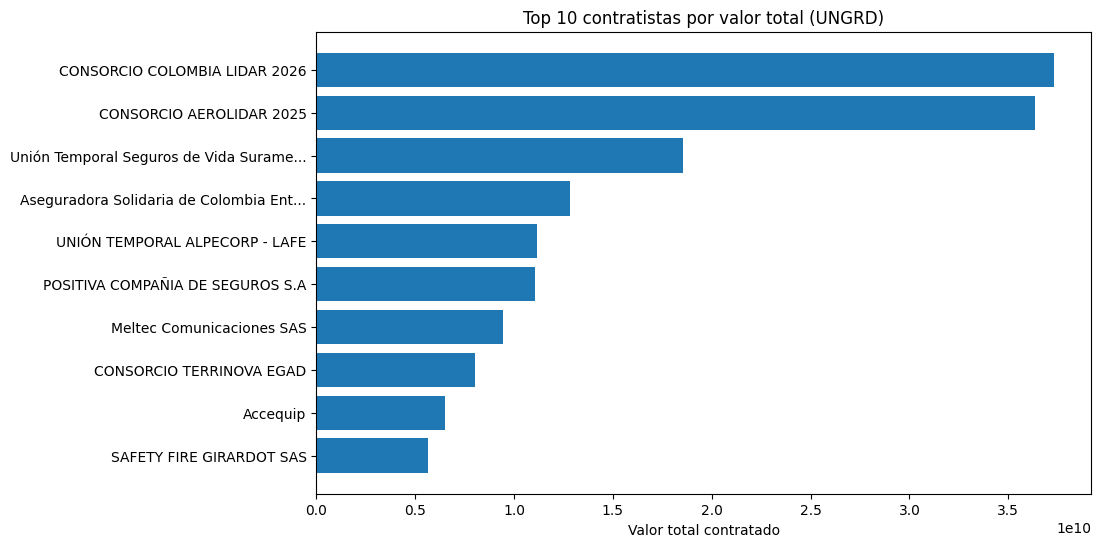

In [137]:
import matplotlib.pyplot as plt

nombres_cortos = [n[:37] + '...' if len(n) > 40 else n for n in top_contratistas.index]

plt.figure(figsize=(10, 6))
plt.barh(nombres_cortos, top_contratistas.values)
plt.xlabel('Valor total contratado')
plt.title('Top 10 contratistas por valor total (UNGRD)')
plt.gca().invert_yaxis()
plt.show()

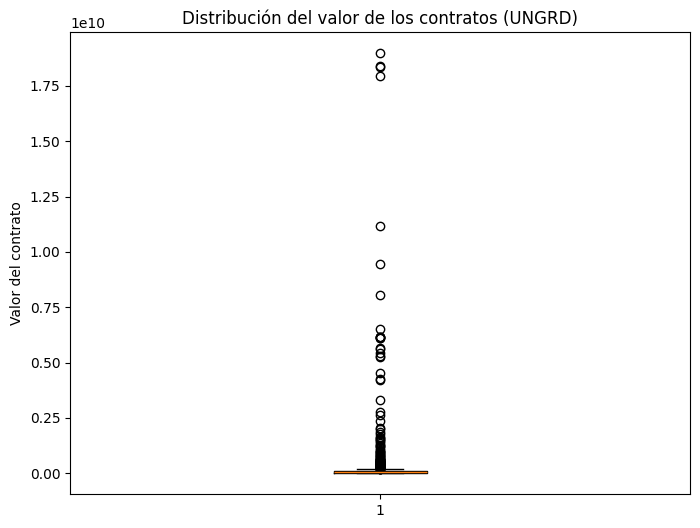

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot(df_analisis['valor_del_contrato'])
plt.ylabel('Valor del contrato')
plt.title('Distribución del valor de los contratos (UNGRD)')
plt.show()